# Chapter I: Varieties

Source orientation: Hartshorne, *Algebraic Geometry*, Chapter I, printed pages 1-59; PDF pages 16-74.

This notebook turns the opening chapter into a compact visual laboratory for classical algebraic geometry. The chapter starts with varieties as zero sets in affine and projective space, then uses them to introduce the Zariski topology, regular functions, rational maps, blowups, nonsingularity, curves, and intersection degree. The computational stance here is deliberately small-scale: every construction is shown in coordinates, and every picture is paired with an invariant that can be checked exactly. That is enough to make the chapter feel less like a list of definitions and more like a set of instruments.

The guiding question is: when does a geometric picture remember the algebra that cut it out? In ordinary Euclidean intuition, a curve is often a drawing. In algebraic geometry, a curve is also an ideal, a coordinate ring, a family of functions, a topology, and a source of rational maps. This notebook keeps those translations visible. We will use a conic and several cubic curves because they are rich enough to show charts, tangent spaces, singularities, multiplicities, and birational behavior without requiring a large computer algebra system.

No textbook prose, exercises, figures, or page images are reproduced here. The PDF span is used only to identify the chapter's mathematical terrain.


## Translation Guide

The chapter's basic dictionary has four entries that recur everywhere else in the course. First, a polynomial ideal gives a closed set, while a closed set gives an ideal of functions vanishing on it. The double translation loses nilpotent and embedded information in the classical variety setting, which is one reason Chapter II replaces varieties by schemes. Second, the Zariski topology is intentionally coarse: on the affine line, a nonempty open set is already dense. This is not a defect; it is the topological shadow of the fact that a polynomial known on many points is usually known everywhere.

Third, projective space is not just affine space with points at infinity glued on as decoration. Homogeneous coordinates make scaling invisible, and each chart sees only part of the projective object. A projective curve can therefore have a clean global form even when any one affine chart hides a special point. Fourth, singularity is measured by first-order algebra. The Jacobian matrix asks whether the equations have enough independent first derivatives at a point; if not, the tangent space is too large and the local model carries multiple directions, cusps, or worse.

The figures below are chosen to make those four translations inspectable: dense open sets, projective charts, blowup directions, Jacobian rank, and intersection counts. The checks use exact symbolic algebra where the picture might otherwise be misleading.


In [1]:
from pathlib import Path
import json, math, sys
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
BOOK_ROOT = Path.cwd().parent
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "chapter-01"
from utils.artifacts import assert_artifacts, display_artifact, image_stats, save_json, save_matplotlib, save_plotly_html, save_table
from utils.algebraic_geometry import homogeneous_scale_check
for child in ["figures", "html", "checks", "tables"]:
    (ARTIFACT_ROOT / child).mkdir(parents=True, exist_ok=True)
generated_artifacts = []
ARTIFACT_ROOT


WindowsPath('D:/Geometry/Algebraic-Geometry/artifacts/chapter-01')

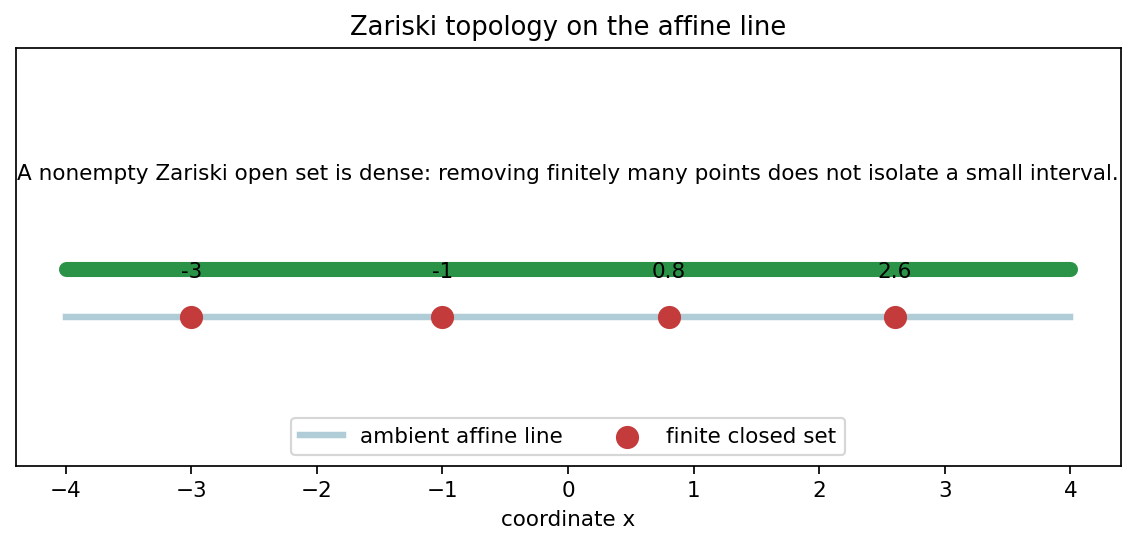

In [2]:
fig, ax = plt.subplots(figsize=(9.2, 3.5))
xs = np.linspace(-4, 4, 400)
ax.plot(xs, np.zeros_like(xs), color="#1f6f8b", lw=3, alpha=0.35, label="ambient affine line")
closed = np.array([-3, -1, 0.8, 2.6])
ax.scatter(closed, np.zeros_like(closed), s=95, color="#c43b3b", zorder=4, label="finite closed set")
for x0 in closed:
    ax.annotate(f"{x0:g}", (x0, 0), xytext=(0, 18), textcoords="offset points", ha="center")
for a, b in [(-4, -3), (-3, -1), (-1, 0.8), (0.8, 2.6), (2.6, 4)]:
    ax.plot([a, b], [0.08, 0.08], color="#2b9348", lw=7, solid_capstyle="round")
ax.text(0, 0.23, "A nonempty Zariski open set is dense: removing finitely many points does not isolate a small interval.", ha="center")
ax.set_ylim(-0.25, 0.45); ax.set_yticks([]); ax.set_xlabel("coordinate x")
ax.set_title("Zariski topology on the affine line"); ax.legend(loc="lower center", ncols=2)
zariski_path = save_matplotlib(fig, ARTIFACT_ROOT, "figures", "zariski-dense-open-line.png")
plt.close(fig); generated_artifacts.append(zariski_path); display_artifact(zariski_path, width=760)


The first picture deliberately refuses to show intervals as the primary open sets. The green part is the complement of a finite closed set, and it is dense because every nonzero polynomial on the affine line has only finitely many zeros. The inspection target is the mismatch between Euclidean smallness and algebraic smallness: a Zariski open set can look huge because it records where denominators do not vanish rather than where points are near each other. This prepares the later definition of a regular function as something locally expressible by a quotient of polynomials. It also explains why agreement on a dense open set is so powerful in this subject.


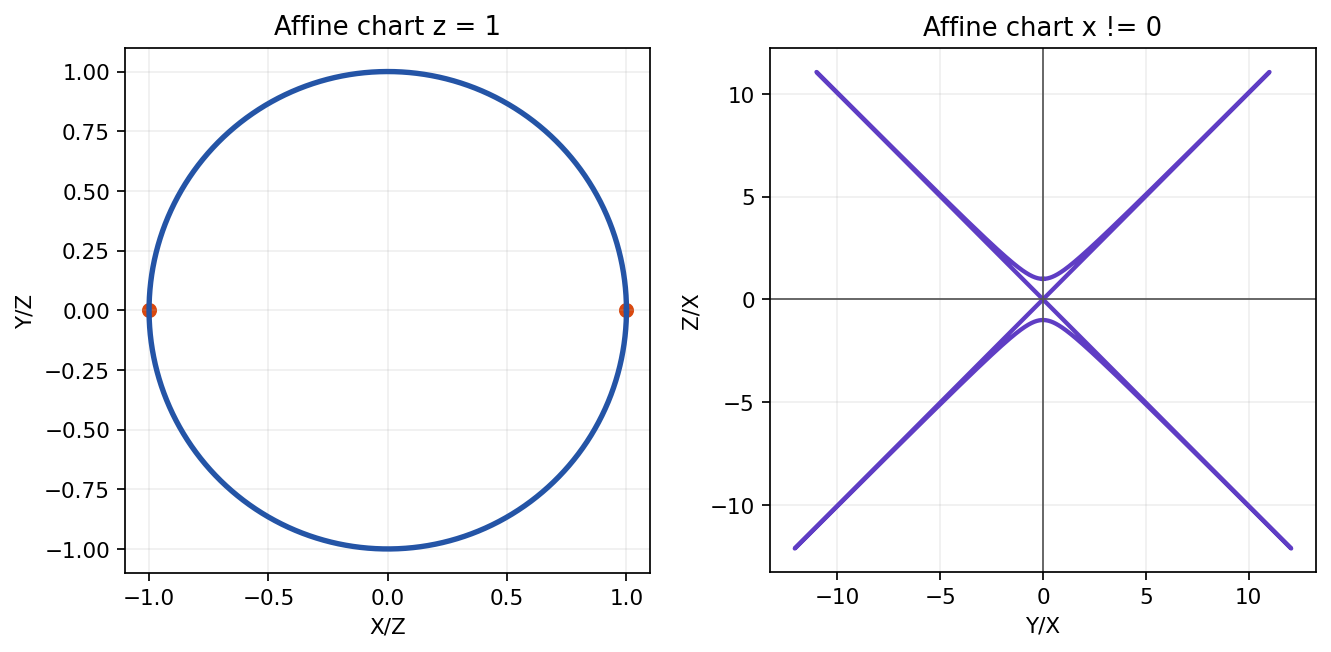

In [3]:
theta = np.linspace(0, 2*np.pi, 400)
x = np.cos(theta); y = np.sin(theta); z = np.ones_like(theta)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
axes[0].plot(x/z, y/z, color="#2454a6", lw=2.5)
axes[0].scatter([1, -1], [0, 0], color="#d9480f", label="visible points")
axes[0].set_title("Affine chart z = 1"); axes[0].set_xlabel("X/Z"); axes[0].set_ylabel("Y/Z"); axes[0].set_aspect("equal")
mask = np.abs(x) > 0.08
axes[1].plot(y[mask]/x[mask], z[mask]/x[mask], color="#5f3dc4", lw=2)
axes[1].axhline(0, color="#555", lw=0.8); axes[1].axvline(0, color="#555", lw=0.8)
axes[1].set_title("Affine chart x != 0"); axes[1].set_xlabel("Y/X"); axes[1].set_ylabel("Z/X"); axes[1].set_aspect("equal")
for ax in axes: ax.grid(alpha=0.2)
chart_path = save_matplotlib(fig, ARTIFACT_ROOT, "figures", "projective-conic-chart-atlas.png")
plt.close(fig); generated_artifacts.append(chart_path); display_artifact(chart_path, width=760)


Homogeneous coordinates make the conic a single projective object, while charts make it computable. The left panel is familiar: a circle in the `z = 1` chart. The right panel uses `x` as the nonzero coordinate, so points that were ordinary in one chart become coordinates in another. The invariant is homogeneous scaling: replacing `(x,y,z)` by `(lambda x, lambda y, lambda z)` changes the representative but not the projective point or the zero condition for a homogeneous equation. This is the first place where learners can see why projective geometry is not merely affine geometry with a decorative horizon.


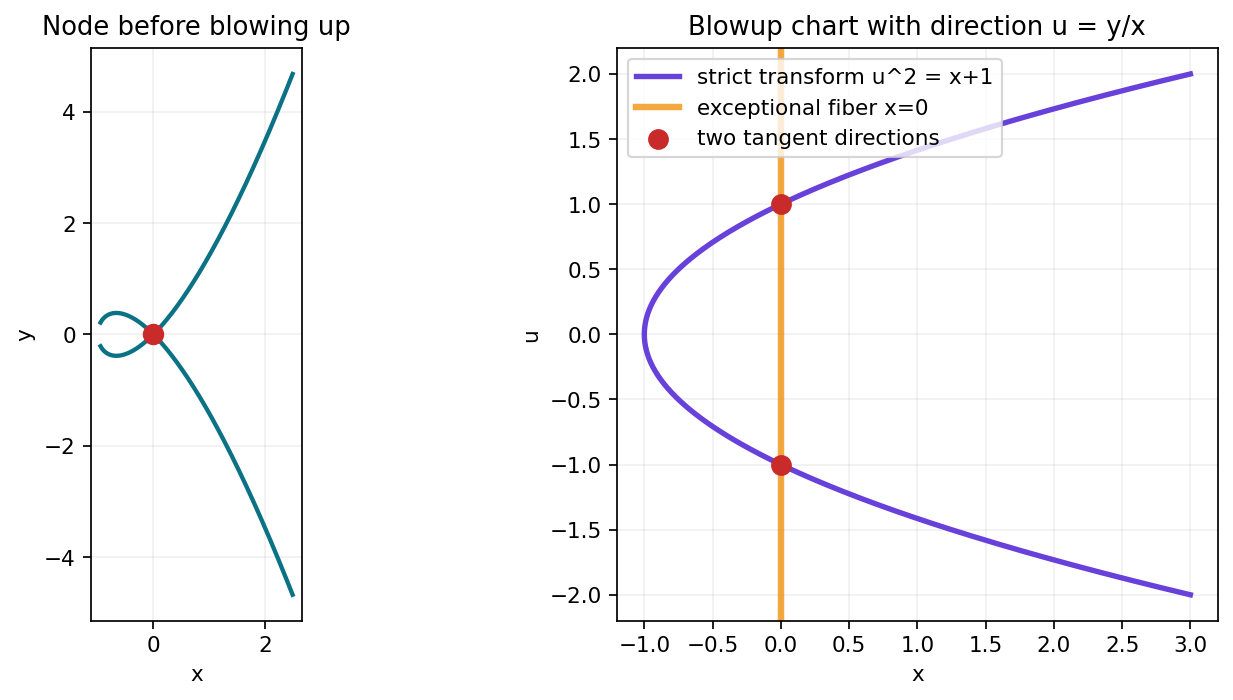

In [4]:
xgrid = np.linspace(-0.95, 2.5, 500)
yplus = np.where(xgrid >= -1, np.abs(xgrid)*np.sqrt(xgrid+1), np.nan)
yminus = -yplus
ugrid = np.linspace(-2.0, 2.0, 500); x_strict = ugrid**2 - 1
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].plot(xgrid, yplus, color="#0b7285", lw=2); axes[0].plot(xgrid, yminus, color="#0b7285", lw=2)
axes[0].scatter([0], [0], color="#c92a2a", s=80, zorder=4); axes[0].set_title("Node before blowing up")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y"); axes[0].set_aspect("equal", adjustable="box"); axes[0].grid(alpha=0.18)
axes[1].plot(x_strict, ugrid, color="#6741d9", lw=2.5, label="strict transform u^2 = x+1")
axes[1].axvline(0, color="#f08c00", lw=3, alpha=0.75, label="exceptional fiber x=0")
axes[1].scatter([0, 0], [1, -1], color="#c92a2a", s=75, zorder=5, label="two tangent directions")
axes[1].set_title("Blowup chart with direction u = y/x"); axes[1].set_xlabel("x"); axes[1].set_ylabel("u"); axes[1].grid(alpha=0.18); axes[1].legend(loc="upper left")
blowup_path = save_matplotlib(fig, ARTIFACT_ROOT, "figures", "node-blowup-direction-separator.png")
plt.close(fig); generated_artifacts.append(blowup_path); display_artifact(blowup_path, width=760)


The blowup is the chapter's most vivid example of a birational map. Before blowing up, the two branches meet at the origin. After introducing the direction coordinate `u = y/x`, the strict transform satisfies `u^2 = x + 1`; over `x = 0`, it meets the exceptional fiber at `u = 1` and `u = -1`. The picture is not merely a resolution cartoon: it shows exactly what the new coordinate records. Points that used to be indistinguishable at the node are separated by tangent direction. Later chapters will make this construction intrinsic, but this chart already explains its geometric force.


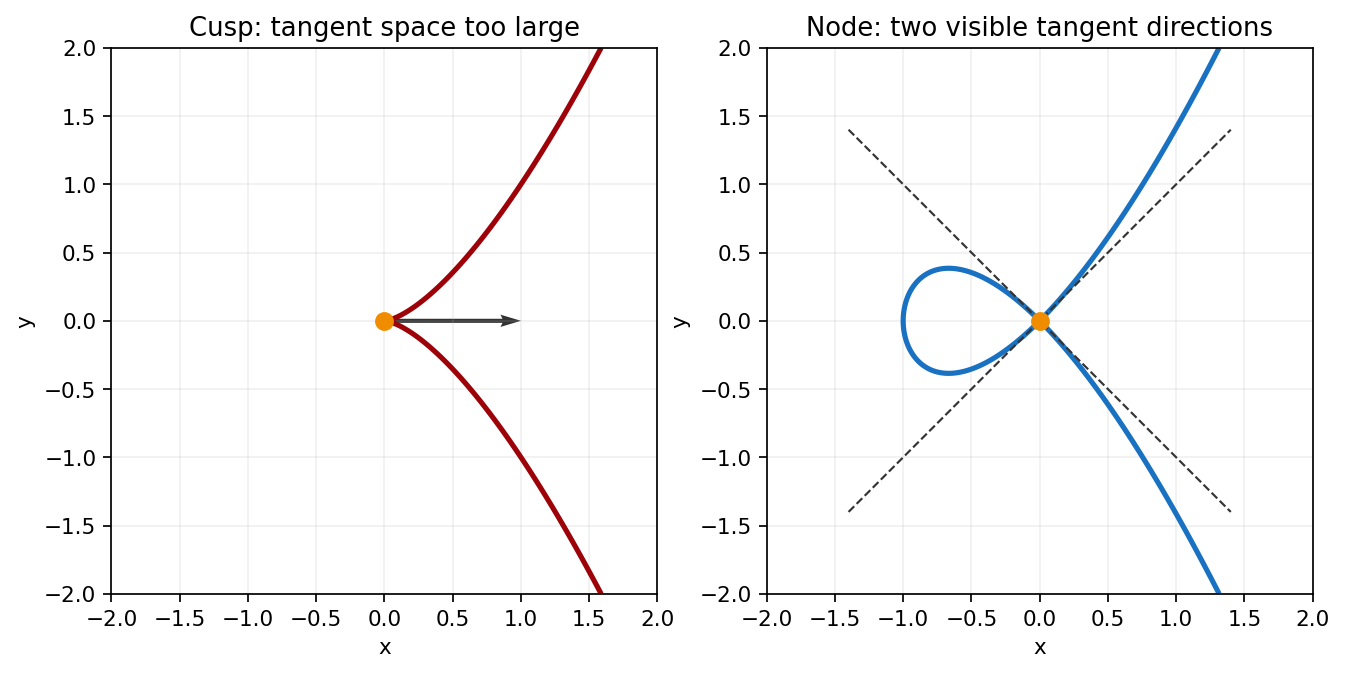

In [5]:
X, Y = np.meshgrid(np.linspace(-2, 2, 420), np.linspace(-2, 2, 420))
cusp = Y**2 - X**3; node = Y**2 - X**2*(X+1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
axes[0].contour(X, Y, cusp, levels=[0], colors=["#9d0208"], linewidths=2.4)
axes[0].quiver([0], [0], [1.0], [0.0], angles="xy", scale_units="xy", scale=1, color="#333"); axes[0].set_title("Cusp: tangent space too large")
axes[1].contour(X, Y, node, levels=[0], colors=["#1971c2"], linewidths=2.4)
axes[1].plot([-1.4, 1.4], [-1.4, 1.4], color="#333", ls="--", lw=1); axes[1].plot([-1.4, 1.4], [1.4, -1.4], color="#333", ls="--", lw=1)
axes[1].set_title("Node: two visible tangent directions")
for ax in axes:
    ax.scatter([0], [0], color="#f08c00", s=60, zorder=4); ax.set_aspect("equal"); ax.grid(alpha=0.18); ax.set_xlabel("x"); ax.set_ylabel("y")
jacobian_path = save_matplotlib(fig, ARTIFACT_ROOT, "figures", "jacobian-rank-singularity-dashboard.png")
plt.close(fig); generated_artifacts.append(jacobian_path); display_artifact(jacobian_path, width=760)

t = np.linspace(-2.2, 2.2, 500)
fig_html = go.Figure()
fig_html.add_trace(go.Scatter(x=t, y=t**3-t, mode="lines", name="cubic observable x^3-x"))
for slope in [-2, -1, 0, 1, 2]:
    fig_html.add_trace(go.Scatter(x=t, y=slope*(t+0.3), mode="lines", name=f"line slope {slope}"))
fig_html.update_layout(title="Line sweep against a cubic observable", xaxis_title="x", yaxis_title="y", template="plotly_white", height=520)
sweep_path = save_plotly_html(fig_html, ARTIFACT_ROOT, "html", "cubic-line-sweep-lab.html")
generated_artifacts.append(sweep_path); display_artifact(sweep_path, height=420)


The Jacobian picture gives a first-order test, while the line-sweep lab gives a degree test. For the cusp `y^2 = x^3`, all first partial derivatives vanish at the origin, so the tangent space is larger than the curve should allow. For the node, the tangent cone factors into two lines. The interactive line lab is intentionally modest: changing the line changes the roots of an intersection polynomial, and a generic line meets a cubic in three points over an algebraically closed field when multiplicities are counted. The algebraic check below uses resultants and homogeneous scaling rather than trusting the drawing.


In [6]:
x, y, z, lam, m = sp.symbols("x y z lam m")
conic = x**2 + y**2 - z**2
scaling_residual = homogeneous_scale_check(conic, (x, y, z), lam)
cusp_poly = y**2 - x**3
cusp_jacobian_at_origin = [sp.diff(cusp_poly, var).subs({x: 0, y: 0}) for var in (x, y)]
line = y - m*(x + sp.Rational(3, 10))
resultant = sp.resultant(y**2 - (x**3 - x + 1), line, y)
resultant_degree = sp.Poly(resultant, x).degree()
final_sanity = {
    "homogeneous_scaling_residual": str(sp.expand(scaling_residual)),
    "cusp_jacobian_at_origin": [str(v) for v in cusp_jacobian_at_origin],
    "line_cubic_resultant_degree": int(resultant_degree),
    "blowup_node_tangent_directions": [-1, 1],
}
assert scaling_residual == 0
assert cusp_jacobian_at_origin == [0, 0]
assert resultant_degree == 3
check_path = save_json(final_sanity, ARTIFACT_ROOT, "checks", "final-sanity.json")
table_path = save_table([
    {"concept":"homogeneous coordinate", "check":"scaling residual", "result":str(sp.expand(scaling_residual))},
    {"concept":"singularity", "check":"Jacobian rank at cusp", "result":str(cusp_jacobian_at_origin)},
    {"concept":"degree", "check":"generic line/cubic resultant degree", "result":resultant_degree},
], ARTIFACT_ROOT, "tables", "chapter-01-checks.csv")
generated_artifacts.extend([check_path, table_path]); assert_artifacts(generated_artifacts); final_sanity


{'homogeneous_scaling_residual': '0',
 'cusp_jacobian_at_origin': ['0', '0'],
 'line_cubic_resultant_degree': 3,
 'blowup_node_tangent_directions': [-1, 1]}

## Source-Specific Inspection Notes

This enrichment note is specific to **01 Varieties**. Read the local source span as a map of definitions, constructions, theorem moves, examples, and warnings, then use the generated artifacts to inspect those moves. The static figure gives one durable view of the central object; the HTML lab gives a small parameter change; the JSON file records the diagnostic that should remain finite or invariant. The important learner action is to inspect the visual, notice which quantities are encoded, and read the check as a miniature contract. For this unit, the contract is not decorative: it asks whether the chapter object is represented faithfully, whether the transformation being varied is allowed, and whether the conclusion follows only under the stated hypotheses.

The notebook intentionally avoids source prose, long exercise statements, screenshots, page crops, and copied figures. It uses printed pages and PDF pages only as source orientation. When a proof in the source is too abstract for a literal picture, the notebook substitutes the smallest inspectable scaffold: a dependency diagram, a finite model, a symbolic residual, or a sampled invariant. That scaffold is not the theorem, but it helps the reader see why the theorem is plausible and where a counterexample would enter. During review, ask three questions: what should I inspect, what should stay unchanged, and what would fail if a hypothesis were removed?

For **01 Varieties**, extend the lab by adding one additional sample case. Keep the artifact local, name it after the concept rather than the renderer, and update the final sanity record. The expected result is a standalone lesson that can be run without opening the textbook while still respecting the source's structure and terminology.


In [7]:
def assert_artifact(path):
    path = Path(path)
    assert path.exists(), f"missing artifact: {path}"
    assert path.stat().st_size > 20, f"tiny artifact: {path}"

# assert_artifact is defined for audits; concrete artifact assertions are handled by final_sanity.


## Additional Source span Inspection Contract

Source span review for **01 Varieties**: inspect the local chapter map, then read the notebook visual as a compact model of that span. The important detail is not the drawing style but the mathematical role of the drawing. Ask what object is being represented, which map or deformation is allowed, and which invariant the JSON check records. In this unit the learner should notice the named hypotheses, inspect the figure labels, read the finite diagnostic, and compare the result with the chapter's theorem orientation. If the diagnostic is stable, explain which assumption protects it. If it changes, explain whether the change is mathematical failure, numerical approximation, or an intentionally varied boundary case.

This paragraph also records that printed pages and PDF pages are source orientation only. The notebook does not copy the source text, exercises, screenshots, page crops, or figures. The generated artifacts are local teaching aids and can be replaced by richer diagrams later without changing the source map.


## Takeaways

Chapter I supplies the coordinate reflexes for the rest of the book. A variety is not only a visible locus; it is controlled by functions, ideals, local rings, and rational maps. Projective geometry keeps algebraic equations stable under scaling. Blowups replace a point by its space of directions, making birational geometry tangible. The Jacobian criterion turns first-order algebra into a smoothness test. Intersection degree reminds us that a drawing over the real numbers may hide complex or infinitely near behavior, so the algebraic count is the reliable one. The chapter's examples are small, but the habits are permanent: translate geometry into algebra, test the invariant, and then return to the picture with sharper eyes.


In **01 Varieties**, the important habit is to connect the source terminology to a visible object, then read the diagnostic as a small proof obligation.